Analýza na úrovni ORP

In [1]:
import pandas as pd
import geopandas as gpd
import esda
import matplotlib.pyplot as plt
from libpysal import graph

import seaborn as sns

In [2]:
skolky_body = gpd.read_parquet("skolky_body_11.parquet")
skolky_body

,Zřizovate,Kraj,Okres_Obvo,Název_ORP,Plný_náz,Zkrácený,Část_obc,Místo,WWW,monthly_fe,X,Y,geometry
RED_IZO,,,,,,,,,,,,,
600035140.0,2.0,Hlavní město Praha,Praha 1,Hlavní město Praha,Mateřská škola Letenská,MŠ Letenská,Malá Strana,Praha,www.msletenska.cz,1000.0,-744048.524881,-1.042980e+06,POINT (-744048.525 -1042979.657)
600035174.0,2.0,Hlavní město Praha,Praha 1,Hlavní město Praha,Mateřská škola Revoluční,MŠ Revoluční,Nové Město,Praha,www.msrevolucni.cz,1140.0,-742655.357048,-1.043956e+06,POINT (-742655.357 -1043955.511)
600035191.0,2.0,Hlavní město Praha,Praha 1,Hlavní město Praha,Mateřská škola Národní se zaměřením na ranou péči,MŠ Národní se zaměřením na ranou péči,Staré Město,Praha,www.msnarodni.cz,900.0,-742975.836508,-1.043008e+06,POINT (-742975.837 -1043007.925)
600035417.0,2.0,Hlavní město Praha,Praha 2,Hlavní město Praha,"Mateřská škola ""Čtyřlístek"", Praha 2, Římská 27","Mateřská škola ""Čtyřlístek""",Vinohrady,Praha,www.ctyrlistek.biz,1100.0,-740952.084102,-1.044655e+06,POINT (-740952.084 -1044654.874)
600035425.0,2.0,Hlavní město Praha,Praha 2,Hlavní město Praha,"Mateřská škola, Praha 2, Slovenská 27",Mateřská škola,Vinohrady,Praha,www.msslovenska.cz,1100.0,-740952.084102,-1.044655e+06,POINT (-740952.084 -1044654.874)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
691016852.0,2.0,Moravskoslezský kraj,Bruntál,Bruntál,"Mateřská škola Světlá Hora, příspěvková organi...",Mateřská škola Světlá Hora,Světlá,Světlá Hora,https://www.mssvetlahora.cz/,500.0,-531386.491099,-1.072142e+06,POINT (-531386.491 -1072141.647)
691017026.0,2.0,Jihomoravský kraj,Brno-město,Brno,"Mateřská škola MAXÍK, Brno, Nad Dědinou 23, př...",Mateřská škola MAXÍK,Bystrc,Brno,https://msmaxik.cz/,850.0,-607058.979381,-1.155567e+06,POINT (-607058.979 -1155566.568)
691017140.0,2.0,Zlínský kraj,Vsetín,Rožnov pod Radhoštěm,Mateřská škola Prostřední Bečva,Mateřská škola Prostřední Bečva,Prostřední Bečva,Prostřední Bečva,http://www.msprostrednibecva.cz,400.0,-475386.907250,-1.142989e+06,POINT (-475386.907 -1142988.587)


In [3]:
obce_polygony = gpd.read_file("geometrie/obce_slbd.geojson").to_crs(5514)

In [4]:
obce_polygony = obce_polygony[["geometry","celkem", "Kód_obce"]]

In [47]:
skolky_body = gpd.read_file("geometrie/body_skolky.shp")


In [55]:
pocet_skolek = gpd.sjoin(skolky_body, obce_polygony, how="inner", predicate="within")
obce_polygony["count"] = pocet_skolek.groupby("index_right").size()
#obce_polygony["count"] = obce_polygony["count"].fillna(0)



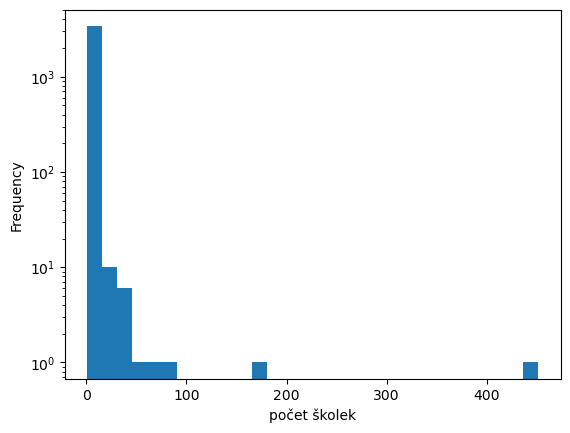

In [56]:
plt.hist(obce_polygony["count"], bins=30)
plt.yscale("log")
plt.xlabel("počet školek")
plt.ylabel("Frequency")
plt.show()


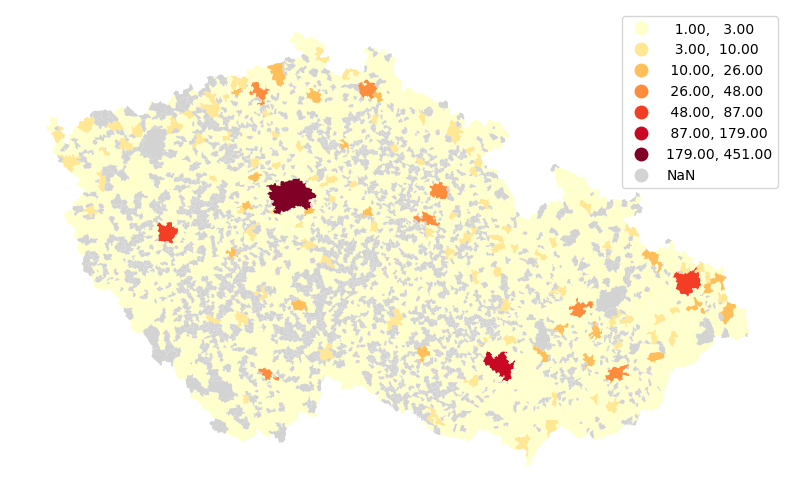

In [63]:
obce_polygony.plot(
    "count",
    figsize=(10,20),
    scheme="natural_breaks",
    k=7,
    cmap= "YlOrRd",
    missing_kwds={"color": "lightgray"},

    legend=True).set_axis_off()

In [6]:
obce_skolky= gpd.sjoin(skolky_body,obce_polygony)

In [7]:
obce_skolky = obce_skolky[["Kraj", "monthly_fe", "celkem", "Kód_obce"]]

In [8]:
obce_skolky

,Kraj,monthly_fe,celkem,Kód_obce
RED_IZO,,,,
600035140.0,Hlavní město Praha,1000.0,1301432.0,554782
600035174.0,Hlavní město Praha,1140.0,1301432.0,554782
600035191.0,Hlavní město Praha,900.0,1301432.0,554782
600035417.0,Hlavní město Praha,1100.0,1301432.0,554782
600035425.0,Hlavní město Praha,1100.0,1301432.0,554782
...,...,...,...,...
691016852.0,Moravskoslezský kraj,500.0,1340.0,597872
691017026.0,Jihomoravský kraj,850.0,398510.0,582786
691017140.0,Zlínský kraj,400.0,1711.0,544698


In [34]:
bins = [0, 10_000, 20_000, 50_000, 100_000, 500_000, float('inf')]
labels = [1, 2, 3, 4, 5,6]

obce_skolky["size_category"] = pd.cut(
    obce_skolky["celkem"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)


In [41]:
std_price = obce_skolky.groupby('Kód_obce').agg({
    'monthly_fe': 'std',
    **{col: 'first' for col in obce_skolky.columns if col not in ['Kód_obce','monthly_fe']}
})


In [36]:
avg_price = obce_skolky.groupby('Kód_obce').agg({
    'monthly_fe': 'mean',
    **{col: 'first' for col in obce_skolky.columns if col not in ['Kód_obce','monthly_fe']}
})


In [37]:
avg = avg_price.pivot_table(
    values="monthly_fe",
    index="Kraj",
    columns="size_category",
    aggfunc="mean"
)
avg


/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_97957/1917703586.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  avg = avg_price.pivot_table(


size_category,1,2,3,4,5,6
Kraj,,,,,,
Hlavní město Praha,NaN,NaN,NaN,NaN,NaN,1191.76506
Jihomoravský kraj,440.629630,750.000000,537.500000,NaN,848.671875,NaN
Jihočeský kraj,378.202247,362.500000,457.500000,420.000000,NaN,NaN
Karlovarský kraj,477.037037,566.666667,632.222222,NaN,NaN,NaN
Kraj Vysočina,344.466667,500.000000,750.000000,700.000000,NaN,NaN
Královéhradecký kraj,420.428571,675.000000,NaN,575.000000,NaN,NaN
Liberecký kraj,473.461538,700.000000,730.000000,NaN,862.000000,NaN
Moravskoslezský kraj,457.256098,466.333333,576.428571,641.515152,747.428571,NaN
Olomoucký kraj,371.216867,622.000000,800.000000,NaN,625.000000,NaN


In [38]:
avg.mean(axis=0)

size_category
1     438.127376
2     625.970696
3     643.637566
4     649.975233
5     756.620089
6    1191.765060
dtype: float64

In [42]:
std = std_price.pivot_table(
    values="monthly_fe",
    index="Kraj",
    columns="size_category",
    aggfunc="mean"
)
std


/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_97957/3505189901.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  std = std_price.pivot_table(


size_category,1,2,3,4,5,6
Kraj,,,,,,
Hlavní město Praha,NaN,NaN,NaN,NaN,NaN,233.597061
Jihomoravský kraj,0.000000,0.000000,21.650635,NaN,156.098875,NaN
Jihočeský kraj,0.000000,35.355339,0.000000,0.000000,NaN,NaN
Karlovarský kraj,70.710678,NaN,19.245009,NaN,NaN,NaN
Kraj Vysočina,NaN,0.000000,0.000000,141.421356,NaN,NaN
Královéhradecký kraj,70.710678,53.033009,NaN,86.602540,NaN,NaN
Liberecký kraj,87.209836,141.421356,0.000000,NaN,55.603757,NaN
Moravskoslezský kraj,0.000000,0.000000,45.955521,56.497072,214.563070,NaN
Olomoucký kraj,NaN,0.000000,0.000000,NaN,61.237244,NaN


In [43]:
std.mean(axis=0)

size_category
1     40.725464
2     24.129441
3     13.198591
4     57.690352
5     97.500589
6    233.597061
dtype: float64

In [ ]:
do 199
200-499
500-999
1000-1999
2000-4999
5000-9999
10000-49999
50-99
100.000+
krajskamesta, mestsje obce, venkonvske obce, hl praha